In [13]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
import igraph as ig
import random as random
from GmGM import GmGM, Dataset
from MED_MAGMA import fast_kronecker_sum_model, quotient, EM_algorithm, sparse_quotient
import scanpy as sc
import anndata as ad
import warnings

%load_ext line_profiler
%load_ext autoreload
%autoreload 2

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Helper functions

In [14]:
# Create a graph from an adjacency structure
def make_graph(graph):
    ground_truth = np.array(graph.get_adjacency().data)
    gt_sums = 1 / np.sqrt(ground_truth.sum(axis=0))
    ground_truth = gt_sums.reshape(1, -1) * ground_truth * gt_sums.reshape(-1, 1)

    # Add diagonal so that it forms a PSD matrix!
    ground_truth = ground_truth / 1.1 + np.eye(ground_truth.shape[0])
    return ground_truth

In [15]:
def keep_top_k_per_row(matrix, k):
        matrix = np.abs(matrix)
        new_matrix = np.zeros_like(matrix)
        for i in range(matrix.shape[0]):
            row = matrix[i]
            top_k_indices = np.argsort(row)[-k:]
            new_matrix[i, top_k_indices] = row[top_k_indices]
        # re-symmetrize
        new_matrix += new_matrix.T
        return new_matrix

In [16]:
def get_aupr(Rs, truths):
    truths1_bin = (np.abs(truths[0]) > 0).astype(int)
    truths2_bin = (np.abs(truths[1]) > 0).astype(int)
    truths1_bin = truths1_bin[np.tril_indices_from(truths1_bin, k=-1)]
    truths2_bin = truths2_bin[np.tril_indices_from(truths2_bin, k=-1)]

    auprs = dict()

    for name, (R1, R2) in Rs.items():
        R1_scores = np.abs(R1[np.tril_indices_from(R1, k=-1)])
        R2_scores = np.abs(R2[np.tril_indices_from(R2, k=-1)])

        precision1, recall1, _ = metrics.precision_recall_curve(truths1_bin, R1_scores)
        precision2, recall2, _ = metrics.precision_recall_curve(truths2_bin, R2_scores)

        aupr1 = metrics.auc(recall1, precision1)
        aupr2 = metrics.auc(recall2, precision2)
        auprs[name] = (aupr1, aupr2)

    return auprs

# Figure 2

33 minutes

In [17]:
noise_strengths = np.linspace(0, 1, 10)

em_amis = {ns: [] for ns in noise_strengths}
gmgm_amis = {ns: [] for ns in noise_strengths}
basic_amis = {ns: [] for ns in noise_strengths}
em_assorts = {ns: [] for ns in noise_strengths}
gmgm_assorts = {ns: [] for ns in noise_strengths}
basic_assorts = {ns: [] for ns in noise_strengths}

all_auprs = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    num_runs = 20
    for noise_strength in noise_strengths:
        auprs = []
        print(f"Noise strength: {noise_strength}")
        for i in range(num_runs):
            print(f"\tRunning on generated dataset {i+1} (seed {i}) of {num_runs}")
            # Initialize
            d1 = 100
            d2 = 150
            np.random.seed(i)
            random.seed(i)

            # Create a random graph
            #graph1_c1 = ig.Graph.Barabasi(n=d1//2)
            #graph1_c2 = ig.Graph.Barabasi(n=d1-d1//2)
            graph1 = make_graph(ig.Graph.Barabasi(n=d1))
            #graph1 = make_graph(graph1_c1.disjoint_union(graph1_c2))
            graph2 = make_graph(ig.Graph.Barabasi(n=d2))
            source = fast_kronecker_sum_model(graph1, graph2)
            r1 = (np.random.chisquare(df=1, size=(d1, 1))) ** noise_strength
            r2 = (np.random.chisquare(df=1, size=(1, d2))) ** noise_strength
            source = r1 * source * r2

            # Cluster on the random graph
            adata = ad.AnnData(source, obsp={"Network": graph1})
            sc.tl.leiden(adata, flavor='igraph', adjacency=adata.obsp["Network"], key_added='true', resolution=1, n_iterations=2)
            # adata.obs['true'] = 0
            # adata.obs.loc[adata.obs.index[:d1//2], 'true'] = 1
            # adata.obs['true'] = adata.obs['true'].astype('category')
            # adata = sc.datasets.blobs(n_variables=d2, n_observations=d1, n_centers=5, cluster_std=0.1)
            # adata.obs['true'] = adata.obs['blobs'].astype('category')

            # if (nc := len(adata.obs['true'].value_counts())) != 4:
            #     print(f"Heads up: seed {i} yielded {nc} natural clusters.")


            # Run GmGM
            pure_gmgm = GmGM(
                Dataset(dataset={"data": (source)}, structure={"data":("row", "col")}),
                threshold_method="overall",
                to_keep=1.0,
                use_nonparanormal_skeptic=False
            )
            C = pure_gmgm.precision_matrices["col"].toarray()
            R = pure_gmgm.precision_matrices["row"].toarray()
            C = C + C.T
            R = R + R.T
            pure_gmgm_results = (R, C)

            # Run EM
            Y = quotient(source)
            EM_results, magnitudes = EM_algorithm(Y, max_iter = 100, verbose=False, very_verbose=False, stop_tol=1e-7, regularization=0)

            # Run basic method
            basic_method = np.linalg.pinv(source @ source.T)
            basic_method_second = np.linalg.pinv(source.T @ source)

            # Check to see AMI
            best_gmgm_ami = -np.inf
            best_em_ami = -np.inf
            best_basic_ami = -np.inf
            best_gmgm_assort = -np.inf
            best_em_assort = -np.inf
            best_basic_assort = -np.inf
            for k in [1, 2, 3, 4, 5, 10, 15, 20, 25]:
                for resolution in np.linspace(0.01, 2, 100):
                    sc.tl.leiden(adata, flavor='igraph', adjacency=keep_top_k_per_row(R, k), key_added='GmGM_estimated', resolution=resolution, n_iterations=2)
                    sc.tl.leiden(adata, flavor='igraph', adjacency=keep_top_k_per_row(EM_results[0], k), key_added='EM_estimated', resolution=resolution, n_iterations=2)
                    sc.tl.leiden(adata, flavor='igraph', adjacency=keep_top_k_per_row(basic_method, k), key_added='Basic_estimated', resolution=resolution, n_iterations=2)

                    cur_gmgm_ami = (
                        metrics.adjusted_mutual_info_score(
                            adata.obs["GmGM_estimated"],
                            adata.obs["true"]
                        )
                    )
                    if cur_gmgm_ami > best_gmgm_ami:
                        best_gmgm_ami = cur_gmgm_ami
                        best_gmgm_assort = ig.Graph.Adjacency(
                            keep_top_k_per_row(R, k) != 0,
                            mode='undirected'
                        ).assortativity(adata.obs['true'].cat.codes.to_numpy())


                    cur_em_ami = (
                        metrics.adjusted_mutual_info_score(
                            adata.obs["EM_estimated"],
                            adata.obs["true"]
                        )
                    )
                    if cur_em_ami > best_em_ami:
                        best_em_ami = cur_em_ami
                        best_em_assort = ig.Graph.Adjacency(
                            keep_top_k_per_row(EM_results[0], k) != 0,
                            mode='undirected'
                        ).assortativity(adata.obs['true'].cat.codes.to_numpy())

                    cur_basic_ami = (
                        metrics.adjusted_mutual_info_score(
                            adata.obs["Basic_estimated"],
                            adata.obs["true"]
                        )
                    )

                    if cur_basic_ami > best_basic_ami:
                        best_basic_ami = cur_basic_ami
                        best_basic_assort = ig.Graph.Adjacency(
                            keep_top_k_per_row(basic_method, k) != 0,
                            mode='undirected'
                        ).assortativity(adata.obs['true'].cat.codes.to_numpy())

            em_amis[noise_strength].append(best_em_ami)
            basic_amis[noise_strength].append(best_basic_ami)
            gmgm_amis[noise_strength].append(best_gmgm_ami)
            em_assorts[noise_strength].append(best_em_assort)
            basic_assorts[noise_strength].append(best_basic_assort)
            gmgm_assorts[noise_strength].append(best_gmgm_assort)

            auprs.append(get_aupr(
                    {
                        "MED-MAGMA": EM_results,
                        "GmGM": (R, C),
                        "Basic": (basic_method, basic_method_second)
                    },
                    (graph1, graph2)
                ))
        all_auprs.append(auprs)

Noise strength: 0.0
	Running on generated dataset 1 (seed 0) of 20
	Running on generated dataset 2 (seed 1) of 20
	Running on generated dataset 3 (seed 2) of 20
	Running on generated dataset 4 (seed 3) of 20
	Running on generated dataset 5 (seed 4) of 20
	Running on generated dataset 6 (seed 5) of 20
	Running on generated dataset 7 (seed 6) of 20
	Running on generated dataset 8 (seed 7) of 20
	Running on generated dataset 9 (seed 8) of 20
	Running on generated dataset 10 (seed 9) of 20
	Running on generated dataset 11 (seed 10) of 20
	Running on generated dataset 12 (seed 11) of 20
	Running on generated dataset 13 (seed 12) of 20
	Running on generated dataset 14 (seed 13) of 20
	Running on generated dataset 15 (seed 14) of 20
	Running on generated dataset 16 (seed 15) of 20
	Running on generated dataset 17 (seed 16) of 20
	Running on generated dataset 18 (seed 17) of 20
	Running on generated dataset 19 (seed 18) of 20
	Running on generated dataset 20 (seed 19) of 20
Noise strength: 0.1

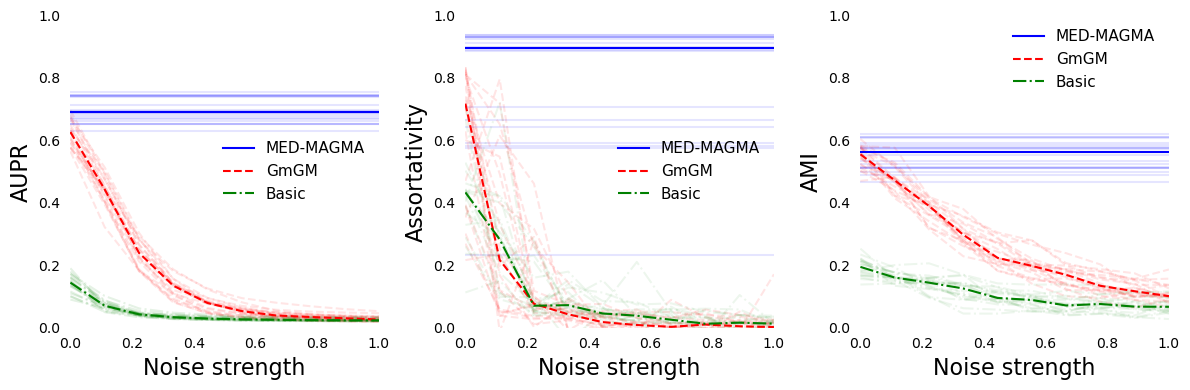

In [18]:
fig, (ax0, ax1, ax2) = plt.subplots(figsize=(12, 4), ncols=3)

color_func=lambda name: "red" if name == "GmGM" else "blue" if name == "MED-MAGMA" else "green"
linestyle_func=lambda name: "--" if name == "GmGM" else "-" if name == "MED-MAGMA" else "-."
alpha=0.1

all_auprs_T = list(zip(*all_auprs))
for auprs in all_auprs_T:
    formatted_auprs: dict[tuple[np.array, np.array]] = {
        "MED-MAGMA": (
            np.array([aupr["MED-MAGMA"][0] for aupr in auprs]),
            np.array([aupr["MED-MAGMA"][1] for aupr in auprs])
        ),
        "GmGM": (
            np.array([aupr["GmGM"][0] for aupr in auprs]),
            np.array([aupr["GmGM"][1] for aupr in auprs])
        ),
        "Basic": (
            np.array([aupr["Basic"][0] for aupr in auprs]),
            np.array([aupr["Basic"][1] for aupr in auprs])
        ),
    }

    for name, (aupr1, aupr2) in formatted_auprs.items():
        ax0.plot(
            noise_strengths,
            aupr1,
            color=color_func(name),
            linestyle=linestyle_func(name),
            alpha=alpha
        )

median_auprs: dict[tuple[np.array, np.array]] = {
    "MED-MAGMA": (
        np.median(np.array([[aupr["MED-MAGMA"][0] for aupr in auprs] for auprs in all_auprs_T]), axis=0),
        np.median(np.array([[aupr["MED-MAGMA"][1] for aupr in auprs] for auprs in all_auprs_T]), axis=0)
    ),
    "GmGM": (
        np.median(np.array([[aupr["GmGM"][0] for aupr in auprs] for auprs in all_auprs_T]), axis=0),
        np.median(np.array([[aupr["GmGM"][1] for aupr in auprs] for auprs in all_auprs_T]), axis=0)
    ),
    "Basic": (
        np.median(np.array([[aupr["Basic"][0] for aupr in auprs] for auprs in all_auprs_T]), axis=0),
        np.median(np.array([[aupr["Basic"][1] for aupr in auprs] for auprs in all_auprs_T]), axis=0)
    )
}

for name, (aupr1, aupr2) in median_auprs.items():
        ax0.plot(
            noise_strengths,
            aupr1,
            label=name,
            color=color_func(name),
            linestyle=linestyle_func(name),
        )
ax0.set_ylabel('AUPR', fontsize=16)


# Assortativity and AMI
em_inversion = np.array(list(zip(*(em_amis[k] for k in noise_strengths))))
gmgm_inversion = np.array(list(zip(*(gmgm_amis[k] for k in noise_strengths))))
basic_inversion = np.array(list(zip(*(basic_amis[k] for k in noise_strengths))))
em_assort_inversion = np.array(list(zip(*(em_assorts[k] for k in noise_strengths))))
gmgm_assort_inversion = np.array(list(zip(*(gmgm_assorts[k] for k in noise_strengths))))
basic_assort_inversion = np.array(list(zip(*(basic_assorts[k] for k in noise_strengths))))

for i, run in enumerate(em_inversion):
    ax2.plot(noise_strengths, run, alpha=alpha, color='blue', linestyle='-')
for i, run in enumerate(gmgm_inversion):
    ax2.plot(noise_strengths, run, alpha=alpha, color='red', linestyle='--')
for i, run in enumerate(em_assort_inversion):
    ax1.plot(noise_strengths, run, alpha=alpha, color='blue', linestyle='-')
for i, run in enumerate(gmgm_assort_inversion):
    ax1.plot(noise_strengths, run, alpha=alpha, color='red', linestyle='--')
for i, run in enumerate(basic_inversion):
    ax2.plot(noise_strengths, run, alpha=0.07, color='green', linestyle='-.')
for i, run in enumerate(basic_assort_inversion):
    ax1.plot(noise_strengths, run, alpha=0.07, color='green', linestyle='-.')

em_median = np.median(em_inversion, axis=0)
gmgm_median = np.median(gmgm_inversion, axis=0)
basic_median = np.median(basic_inversion, axis=0)
em_assort_median = np.median(em_assort_inversion, axis=0)
gmgm_assort_median = np.median(gmgm_assort_inversion, axis=0)
basic_assort_median = np.median(basic_assort_inversion, axis=0)


ax2.plot(noise_strengths, em_median, color='blue', label='MED-MAGMA', linestyle='-')
ax2.plot(noise_strengths, gmgm_median, color='red', label='GmGM', linestyle='--')
ax1.plot(noise_strengths, em_assort_median, color='blue', label='MED-MAGMA', linestyle='-')
ax1.plot(noise_strengths, gmgm_assort_median, color='red', label='GmGM', linestyle='--')
ax2.plot(noise_strengths, basic_median, color='green', label='Basic', linestyle='-.')
ax1.plot(noise_strengths, basic_assort_median, color='green', label='Basic', linestyle='-.')

for ax in (ax0, ax1, ax2):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Noise strength', fontsize=16)
    ax.legend(fontsize=11, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(left=False, bottom=False)


ax1.set_ylabel('Assortativity', fontsize=16)
ax2.set_ylabel('AMI', fontsize=16)

fig.tight_layout()
fig.savefig('./figures/synthetic-aupr-assort-ami-lopsided.pdf')

## Figure 5

In [20]:
noise_strengths = np.linspace(0, 1, 10)

em_amis = {ns: [] for ns in noise_strengths}
gmgm_amis = {ns: [] for ns in noise_strengths}
basic_amis = {ns: [] for ns in noise_strengths}
em_assorts = {ns: [] for ns in noise_strengths}
gmgm_assorts = {ns: [] for ns in noise_strengths}
basic_assorts = {ns: [] for ns in noise_strengths}

all_auprs = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    num_runs = 20
    for noise_strength in noise_strengths:
        auprs = []
        print(f"Noise strength: {noise_strength}")
        for i in range(num_runs):
            print(f"\tRunning on generated dataset {i+1} (seed {i}) of {num_runs}")
            # Initialize
            d1 = 200
            d2 = 201
            np.random.seed(i)
            random.seed(i)

            # Create a random graph
            #graph1_c1 = ig.Graph.Barabasi(n=d1//2)
            #graph1_c2 = ig.Graph.Barabasi(n=d1-d1//2)
            graph1 = make_graph(ig.Graph.Barabasi(n=d1))
            #graph1 = make_graph(graph1_c1.disjoint_union(graph1_c2))
            graph2 = make_graph(ig.Graph.Barabasi(n=d2))
            source = fast_kronecker_sum_model(graph1, graph2)
            r1 = (np.random.chisquare(df=1, size=(d1, 1))) ** noise_strength
            r2 = (np.random.chisquare(df=1, size=(1, d2))) ** noise_strength
            source = r1 * source * r2

            # Cluster on the random graph
            adata = ad.AnnData(source, obsp={"Network": graph1})
            sc.tl.leiden(adata, flavor='igraph', adjacency=adata.obsp["Network"], key_added='true', resolution=1, n_iterations=2)
            # adata.obs['true'] = 0
            # adata.obs.loc[adata.obs.index[:d1//2], 'true'] = 1
            # adata.obs['true'] = adata.obs['true'].astype('category')
            # adata = sc.datasets.blobs(n_variables=d2, n_observations=d1, n_centers=5, cluster_std=0.1)
            # adata.obs['true'] = adata.obs['blobs'].astype('category')

            # if (nc := len(adata.obs['true'].value_counts())) != 4:
            #     print(f"Heads up: seed {i} yielded {nc} natural clusters.")


            # Run GmGM
            pure_gmgm = GmGM(
                Dataset(dataset={"data": (source)}, structure={"data":("row", "col")}),
                threshold_method="overall",
                to_keep=1.0,
                use_nonparanormal_skeptic=False
            )
            C = pure_gmgm.precision_matrices["col"].toarray()
            R = pure_gmgm.precision_matrices["row"].toarray()
            C = C + C.T
            R = R + R.T
            pure_gmgm_results = (R, C)

            # Run EM
            Y = quotient(source)
            EM_results, magnitudes = EM_algorithm(Y, max_iter = 100, verbose=False, very_verbose=False, stop_tol=1e-7, regularization=0)

            # Run basic method
            basic_method = np.linalg.pinv(source @ source.T, rcond=1e-4)
            basic_method_second = np.linalg.pinv(source.T @ source, rcond=1e-4)

            # Check to see AMI
            best_gmgm_ami = -np.inf
            best_em_ami = -np.inf
            best_basic_ami = -np.inf
            best_gmgm_assort = -np.inf
            best_em_assort = -np.inf
            best_basic_assort = -np.inf
            for k in [1, 2, 3, 4, 5, 10, 15, 20, 25]:
                for resolution in np.linspace(0.01, 2, 100):
                    sc.tl.leiden(adata, flavor='igraph', adjacency=keep_top_k_per_row(R, k), key_added='GmGM_estimated', resolution=resolution, n_iterations=2)
                    sc.tl.leiden(adata, flavor='igraph', adjacency=keep_top_k_per_row(EM_results[0], k), key_added='EM_estimated', resolution=resolution, n_iterations=2)
                    sc.tl.leiden(adata, flavor='igraph', adjacency=keep_top_k_per_row(basic_method, k), key_added='Basic_estimated', resolution=resolution, n_iterations=2)

                    cur_gmgm_ami = (
                        metrics.adjusted_mutual_info_score(
                            adata.obs["GmGM_estimated"],
                            adata.obs["true"]
                        )
                    )
                    if cur_gmgm_ami > best_gmgm_ami:
                        best_gmgm_ami = cur_gmgm_ami
                        best_gmgm_assort = ig.Graph.Adjacency(
                            keep_top_k_per_row(R, k) != 0,
                            mode='undirected'
                        ).assortativity(adata.obs['true'].cat.codes.to_numpy())


                    cur_em_ami = (
                        metrics.adjusted_mutual_info_score(
                            adata.obs["EM_estimated"],
                            adata.obs["true"]
                        )
                    )
                    if cur_em_ami > best_em_ami:
                        best_em_ami = cur_em_ami
                        best_em_assort = ig.Graph.Adjacency(
                            keep_top_k_per_row(EM_results[0], k) != 0,
                            mode='undirected'
                        ).assortativity(adata.obs['true'].cat.codes.to_numpy())

                    cur_basic_ami = (
                        metrics.adjusted_mutual_info_score(
                            adata.obs["Basic_estimated"],
                            adata.obs["true"]
                        )
                    )

                    if cur_basic_ami > best_basic_ami:
                        best_basic_ami = cur_basic_ami
                        best_basic_assort = ig.Graph.Adjacency(
                            keep_top_k_per_row(basic_method, k) != 0,
                            mode='undirected'
                        ).assortativity(adata.obs['true'].cat.codes.to_numpy())

                # Finally, let's measure the assortativity of the graph
                # em_assortativity = ig.Graph.Adjacency(
                #     keep_top_k_per_row(EM_results[0], k) != 0,
                #     mode='undirected'
                # ).assortativity(adata.obs['true'].cat.codes.to_numpy())
                # gmgm_assortativity = ig.Graph.Adjacency(
                #     keep_top_k_per_row(R, k) != 0,
                #     mode='undirected'
                # ).assortativity(adata.obs['true'].cat.codes.to_numpy())
                # basic_assortativity = ig.Graph.Adjacency(
                #     keep_top_k_per_row(basic_method, k) != 0,
                #     mode='undirected'
                # ).assortativity(adata.obs['true'].cat.codes.to_numpy())

                # if em_assortativity > best_em_assort:
                #     best_em_assort = em_assortativity
                # if gmgm_assortativity > best_gmgm_assort:
                #     best_gmgm_assort = gmgm_assortativity
                # if basic_assortativity > best_basic_assort:
                #     best_basic_assort = basic_assortativity

            em_amis[noise_strength].append(best_em_ami)
            basic_amis[noise_strength].append(best_basic_ami)
            gmgm_amis[noise_strength].append(best_gmgm_ami)
            em_assorts[noise_strength].append(best_em_assort)
            basic_assorts[noise_strength].append(best_basic_assort)
            gmgm_assorts[noise_strength].append(best_gmgm_assort)

            auprs.append(get_aupr(
                    {
                        "MED-MAGMA": EM_results,
                        "GmGM": (R, C),
                        "Basic": (basic_method, basic_method_second)
                    },
                    (graph1, graph2)
                ))
        all_auprs.append(auprs)

Noise strength: 0.0
	Running on generated dataset 1 (seed 0) of 20
	Running on generated dataset 2 (seed 1) of 20
	Running on generated dataset 3 (seed 2) of 20
	Running on generated dataset 4 (seed 3) of 20
	Running on generated dataset 5 (seed 4) of 20
	Running on generated dataset 6 (seed 5) of 20
	Running on generated dataset 7 (seed 6) of 20
	Running on generated dataset 8 (seed 7) of 20
	Running on generated dataset 9 (seed 8) of 20
	Running on generated dataset 10 (seed 9) of 20
	Running on generated dataset 11 (seed 10) of 20
	Running on generated dataset 12 (seed 11) of 20
	Running on generated dataset 13 (seed 12) of 20
	Running on generated dataset 14 (seed 13) of 20
	Running on generated dataset 15 (seed 14) of 20
	Running on generated dataset 16 (seed 15) of 20
	Running on generated dataset 17 (seed 16) of 20
	Running on generated dataset 18 (seed 17) of 20
	Running on generated dataset 19 (seed 18) of 20
	Running on generated dataset 20 (seed 19) of 20
Noise strength: 0.1

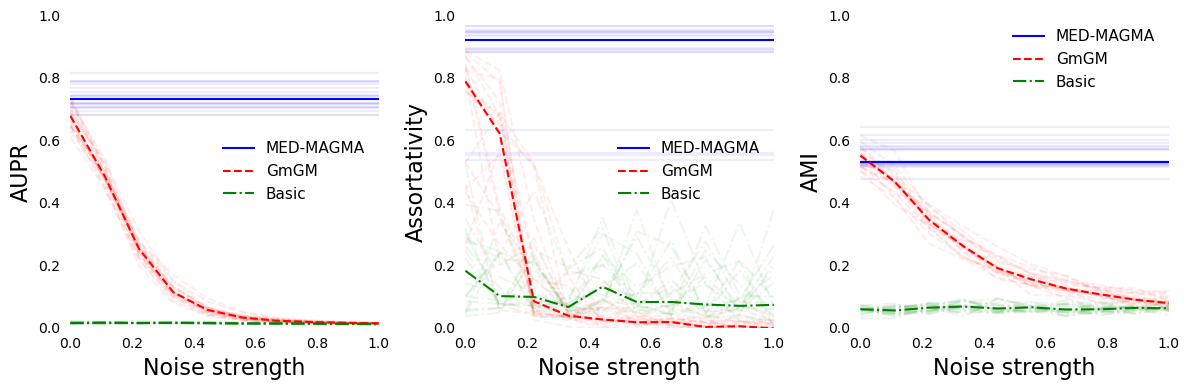

In [21]:
fig, (ax0, ax1, ax2) = plt.subplots(figsize=(12, 4), ncols=3)

color_func=lambda name: "red" if name == "GmGM" else "blue" if name == "MED-MAGMA" else "green"
linestyle_func=lambda name: "--" if name == "GmGM" else "-" if name == "MED-MAGMA" else "-."

all_auprs_T = list(zip(*all_auprs))
for auprs in all_auprs_T:
    formatted_auprs: dict[tuple[np.array, np.array]] = {
        "MED-MAGMA": (
            np.array([aupr["MED-MAGMA"][0] for aupr in auprs]),
            np.array([aupr["MED-MAGMA"][1] for aupr in auprs])
        ),
        "GmGM": (
            np.array([aupr["GmGM"][0] for aupr in auprs]),
            np.array([aupr["GmGM"][1] for aupr in auprs])
        ),
        "Basic": (
            np.array([aupr["Basic"][0] for aupr in auprs]),
            np.array([aupr["Basic"][1] for aupr in auprs])
        ),
    }

    for name, (aupr1, aupr2) in formatted_auprs.items():
        ax0.plot(
            noise_strengths,
            aupr1,
            color=color_func(name),
            linestyle=linestyle_func(name),
            alpha=0.07
        )

median_auprs: dict[tuple[np.array, np.array]] = {
    "MED-MAGMA": (
        np.median(np.array([[aupr["MED-MAGMA"][0] for aupr in auprs] for auprs in all_auprs_T]), axis=0),
        np.median(np.array([[aupr["MED-MAGMA"][1] for aupr in auprs] for auprs in all_auprs_T]), axis=0)
    ),
    "GmGM": (
        np.median(np.array([[aupr["GmGM"][0] for aupr in auprs] for auprs in all_auprs_T]), axis=0),
        np.median(np.array([[aupr["GmGM"][1] for aupr in auprs] for auprs in all_auprs_T]), axis=0)
    ),
    "Basic": (
        np.median(np.array([[aupr["Basic"][0] for aupr in auprs] for auprs in all_auprs_T]), axis=0),
        np.median(np.array([[aupr["Basic"][1] for aupr in auprs] for auprs in all_auprs_T]), axis=0)
    )
}

for name, (aupr1, aupr2) in median_auprs.items():
        ax0.plot(
            noise_strengths,
            aupr1,
            label=name,
            color=color_func(name),
            linestyle=linestyle_func(name),
        )
ax0.set_ylabel('AUPR', fontsize=16)


# Assortativity and AMI
em_inversion = np.array(list(zip(*(em_amis[k] for k in noise_strengths))))
gmgm_inversion = np.array(list(zip(*(gmgm_amis[k] for k in noise_strengths))))
basic_inversion = np.array(list(zip(*(basic_amis[k] for k in noise_strengths))))
em_assort_inversion = np.array(list(zip(*(em_assorts[k] for k in noise_strengths))))
gmgm_assort_inversion = np.array(list(zip(*(gmgm_assorts[k] for k in noise_strengths))))
basic_assort_inversion = np.array(list(zip(*(basic_assorts[k] for k in noise_strengths))))

for i, run in enumerate(em_inversion):
    ax2.plot(noise_strengths, run, alpha=0.07, color='blue', linestyle='-')
for i, run in enumerate(gmgm_inversion):
    ax2.plot(noise_strengths, run, alpha=0.07, color='red', linestyle='--')
for i, run in enumerate(em_assort_inversion):
    ax1.plot(noise_strengths, run, alpha=0.07, color='blue', linestyle='-')
for i, run in enumerate(gmgm_assort_inversion):
    ax1.plot(noise_strengths, run, alpha=0.07, color='red', linestyle='--')
for i, run in enumerate(basic_inversion):
    ax2.plot(noise_strengths, run, alpha=0.07, color='green', linestyle='-.')
for i, run in enumerate(basic_assort_inversion):
    ax1.plot(noise_strengths, run, alpha=0.07, color='green', linestyle='-.')

em_median = np.median(em_inversion, axis=0)
gmgm_median = np.median(gmgm_inversion, axis=0)
basic_median = np.median(basic_inversion, axis=0)
em_assort_median = np.median(em_assort_inversion, axis=0)
gmgm_assort_median = np.median(gmgm_assort_inversion, axis=0)
basic_assort_median = np.median(basic_assort_inversion, axis=0)


ax2.plot(noise_strengths, em_median, color='blue', label='MED-MAGMA', linestyle='-')
ax2.plot(noise_strengths, gmgm_median, color='red', label='GmGM', linestyle='--')
ax1.plot(noise_strengths, em_assort_median, color='blue', label='MED-MAGMA', linestyle='-')
ax1.plot(noise_strengths, gmgm_assort_median, color='red', label='GmGM', linestyle='--')
ax2.plot(noise_strengths, basic_median, color='green', label='Basic', linestyle='-.')
ax1.plot(noise_strengths, basic_assort_median, color='green', label='Basic', linestyle='-.')

for ax in (ax0, ax1, ax2):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Noise strength', fontsize=16)
    ax.legend(fontsize=11, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(left=False, bottom=False)


ax1.set_ylabel('Assortativity', fontsize=16)
ax2.set_ylabel('AMI', fontsize=16)

fig.tight_layout()
fig.savefig('./figures/synthetic-aupr-assort-ami.pdf')

## Figure 6

In [22]:
# Initialize
d1 = 200
d2 = 201
density_auprs = []
densities = np.linspace(0.1, 1, 10)

num_runs = 20
for i in range(num_runs):
    print(f"Running on generated dataset {i+1} (seed {i}) of {num_runs}")
    # Loop over densities strengths
    auprs: list[dict[tuple[float, float]]] = []
    for density in densities:
        np.random.seed(i)
        random.seed(i)

        # Create a random graph
        graph1 = make_graph(ig.Graph.Barabasi(n=d1))
        graph2 = make_graph(ig.Graph.Barabasi(n=d2))
        source = fast_kronecker_sum_model(graph1, graph2)
        r1 = (np.random.chisquare(df=1, size=(d1, 1))) ** 0.2
        r2 = (np.random.chisquare(df=1, size=(1, d2))) ** 0.2

        # sparsify and then add noise
        source *= np.random.binomial(1, p=density, size=(d1, d2))
        source = r1 * source * r2


        # Run GmGM
        pure_gmgm = GmGM(
            Dataset(dataset={"data": (source)}, structure={"data":("row", "col")}),
            threshold_method="overall",
            to_keep=1.0,
            use_nonparanormal_skeptic=False
        )
        C = pure_gmgm.precision_matrices["col"].toarray()
        R = pure_gmgm.precision_matrices["row"].toarray()
        C = C + C.T
        R = R + R.T
        pure_gmgm_results = (R, C)

        # Run EM
        Y = sparse_quotient(source)
        EM_results, magnitudes = EM_algorithm(Y, max_iter = 100, verbose=False, stop_tol=1e-10, regularization=0)

        auprs.append(get_aupr(
            {
                "Robust GmGM": EM_results,
                "Pure GmGM": pure_gmgm_results
            },
            (graph1, graph2)
        ))
    density_auprs.append(auprs)

Running on generated dataset 1 (seed 0) of 20
Running on generated dataset 2 (seed 1) of 20
Running on generated dataset 3 (seed 2) of 20
Running on generated dataset 4 (seed 3) of 20
Running on generated dataset 5 (seed 4) of 20
Running on generated dataset 6 (seed 5) of 20
Running on generated dataset 7 (seed 6) of 20
Running on generated dataset 8 (seed 7) of 20
Running on generated dataset 9 (seed 8) of 20
Running on generated dataset 10 (seed 9) of 20
Running on generated dataset 11 (seed 10) of 20
Running on generated dataset 12 (seed 11) of 20
Running on generated dataset 13 (seed 12) of 20
Running on generated dataset 14 (seed 13) of 20
Running on generated dataset 15 (seed 14) of 20
Running on generated dataset 16 (seed 15) of 20
Running on generated dataset 17 (seed 16) of 20
Running on generated dataset 18 (seed 17) of 20
Running on generated dataset 19 (seed 18) of 20
Running on generated dataset 20 (seed 19) of 20


In [23]:
# Initialize
d1 = 200
d2 = 201
noise_auprs = []
noises = np.linspace(0, 1, 10)

num_runs = 20
for i in range(num_runs):
    print(f"Running on generated dataset {i+1} (seed {i}) of {num_runs}")
    # Loop over densities strengths
    auprs: list[dict[tuple[float, float]]] = []
    for noise in noises:
        np.random.seed(i)
        random.seed(i)

        # Create a random graph
        graph1 = make_graph(ig.Graph.Barabasi(n=d1))
        graph2 = make_graph(ig.Graph.Barabasi(n=d2))
        source = fast_kronecker_sum_model(graph1, graph2)
        r1 = (np.random.chisquare(df=1, size=(d1, 1))) ** noise
        r2 = (np.random.chisquare(df=1, size=(1, d2))) ** noise

        # sparsify and then add noise
        source *= np.random.binomial(1, p=0.5, size=(d1, d2))
        source = r1 * source * r2


        # Run GmGM
        pure_gmgm = GmGM(
            Dataset(dataset={"data": (source)}, structure={"data":("row", "col")}),
            threshold_method="overall",
            to_keep=1.0,
            use_nonparanormal_skeptic=False
        )
        C = pure_gmgm.precision_matrices["col"].toarray()
        R = pure_gmgm.precision_matrices["row"].toarray()
        C = C + C.T
        R = R + R.T
        pure_gmgm_results = (R, C)

        # Run EM
        Y = sparse_quotient(source)
        EM_results, magnitudes = EM_algorithm(Y, max_iter = 100, verbose=False, stop_tol=1e-10, regularization=0)

        auprs.append(get_aupr(
            {
                "Robust GmGM": EM_results,
                "Pure GmGM": pure_gmgm_results
            },
            (graph1, graph2)
        ))
    noise_auprs.append(auprs)

Running on generated dataset 1 (seed 0) of 20
Running on generated dataset 2 (seed 1) of 20
Running on generated dataset 3 (seed 2) of 20
Running on generated dataset 4 (seed 3) of 20
Running on generated dataset 5 (seed 4) of 20
Running on generated dataset 6 (seed 5) of 20
Running on generated dataset 7 (seed 6) of 20
Running on generated dataset 8 (seed 7) of 20
Running on generated dataset 9 (seed 8) of 20
Running on generated dataset 10 (seed 9) of 20
Running on generated dataset 11 (seed 10) of 20
Running on generated dataset 12 (seed 11) of 20
Running on generated dataset 13 (seed 12) of 20
Running on generated dataset 14 (seed 13) of 20
Running on generated dataset 15 (seed 14) of 20
Running on generated dataset 16 (seed 15) of 20
Running on generated dataset 17 (seed 16) of 20
Running on generated dataset 18 (seed 17) of 20
Running on generated dataset 19 (seed 18) of 20
Running on generated dataset 20 (seed 19) of 20


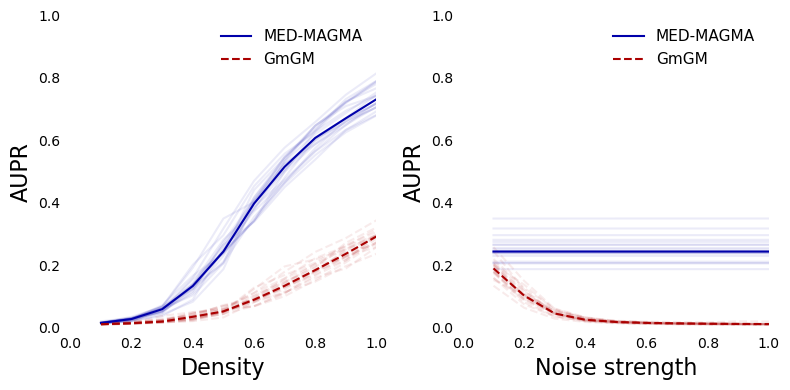

In [24]:
fig, (ax1, ax2) = plt.subplots(figsize=(8, 4), ncols=2)

color_func=lambda name: "#aa0000" if name == "GmGM" else "#0000aa"
linestyle_func=lambda name: "--" if name == "GmGM" else "-"

for special_auprs, ax in zip([density_auprs, noise_auprs], [ax1, ax2]):
    for auprs in special_auprs:
        formatted_auprs: dict[tuple[np.array, np.array]] = {
            "MED-MAGMA": (
                np.array([aupr["Robust GmGM"][0] for aupr in auprs]),
                np.array([aupr["Robust GmGM"][1] for aupr in auprs])
            ),
            "GmGM": (
                np.array([aupr["Pure GmGM"][0] for aupr in auprs]),
                np.array([aupr["Pure GmGM"][1] for aupr in auprs])
            )
        }

        for name, (aupr1, aupr2) in formatted_auprs.items():
            ax.plot(
                densities,
                aupr1,
                color=color_func(name),
                linestyle=linestyle_func(name),
                alpha=0.08
            )

    median_auprs: dict[tuple[np.array, np.array]] = {
        "MED-MAGMA": (
            np.median(np.array([[aupr["Robust GmGM"][0] for aupr in auprs] for auprs in special_auprs]), axis=0),
            np.median(np.array([[aupr["Robust GmGM"][1] for aupr in auprs] for auprs in special_auprs]), axis=0)
        ),
        "GmGM": (
            np.median(np.array([[aupr["Pure GmGM"][0] for aupr in auprs] for auprs in special_auprs]), axis=0),
            np.median(np.array([[aupr["Pure GmGM"][1] for aupr in auprs] for auprs in special_auprs]), axis=0)
        )
    }


    for name, (aupr1, aupr2) in median_auprs.items():
        ax.plot(
            densities,
            aupr1,
            label=name,
            color=color_func(name),
            linestyle=linestyle_func(name),
        )
    ax.set_ylabel('AUPR', fontsize=16)
    ax.legend(loc='upper right', frameon=False, fontsize=11)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)


    # Turn of spines to look prettier
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(left=False, bottom=False)

ax1.set_xlabel('Density', fontsize=16)
ax2.set_xlabel('Noise strength', fontsize=16)

fig.tight_layout()
#fig.savefig('./figures/sparsity-aupr.pdf')